# DQN with Acrobot-v1 Environment

This notebook loads [config.yaml](config.yaml) and trains the `QAgent` on `Acrobot-v1` using the Gymnassium API for envrionment.

Acrobot has a `Box(6,)` **observation space** and a `Discrete(3)` **action space**, so DQN uses the continuous state and the native discrete actions while training, during analysis we break it down based on our analysis discretisation config to look at the various statistics.

## Imports

In [11]:

import sys, pathlib, yaml
from functools import partial
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

SRC = pathlib.Path.cwd().parents[1] / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from environments.base_env import make_environment
from agents.q_agent import QAgent
from training import dqn_training_loop
from analysis.low_rank.hankel_policy import hankel_rollout
from analysis.low_rank.tabular_q_matrix import q_matrix_dqn
from analysis.low_rank.rank import plot_matrix_spectra

## Reading the `config` file

In [2]:
# Reading the experiment config file
with open("config.yaml") as f:
    cfg = yaml.safe_load(f)

# Gathering torch backend and experiment seed
dev = cfg["experiment"]["device"]
device = dev if (dev != "mps" or torch.backends.mps.is_available()) else "cpu"
seed = cfg["experiment"]["seed"]
torch.manual_seed(seed)
np.random.seed(seed)

cfg

{'experiment': {'name': 'dqn_acrobot', 'seed': 52, 'device': 'mps'},
 'environment': {'name': 'Acrobot-v1',
  'render_mode': None,
  'discrete_config': None,
  'normalise': {'action': {}, 'state': {}}},
 'network': {'hidden_sizes': [128, 128]},
 'agent': {'replay_buffer_capacity': 10000,
  'batch_size': 128,
  'nn_learning_rate': 0.0003,
  'eps_start': 1.0,
  'eps_min': 0.05,
  'decay_rate': 0.99995,
  'discount_factor': 0.99,
  'TD_LR': 0.005,
  'buffer_util': 1},
 'training': {'no_episodes': 500, 'target_network_update_steps': 1},
 'analysis': {'ep_freq': 50,
  'methods': [{'name': 'hankel_rollout', 'kwargs': {'seed': 52}},
   {'name': 'q_matrix_dqn',
    'kwargs': {'state_discretisation': [8, 8, 8, 8, 8, 8],
     'batch_size': 64}}]}}

## Creating the Envrionment

In [3]:
env_cfg = cfg["environment"]
env = make_environment(
    env_cfg["name"],
    render_mode=env_cfg["render_mode"],
    discrete_config=env_cfg["discrete_config"],   # None -> no discretisation
    normalise=env_cfg["normalise"],               # {action:{}, state:{}} -> no rescaling
)
obs_dim = env.observation_space.shape[0]         
n_actions = env.action_space.n                    
print("obs_dim:", obs_dim, "n_actions:", n_actions)

obs_dim: 6 n_actions: 3


## Creating the Agent

In [4]:
class QNetwork(nn.Module):
    """Maps a state (obs_dim,) -> Q-values (n_actions,). Built by QAgent via q_network(**nn_extra_kwargs)."""
    def __init__(self, in_dim, out_dim, hidden_sizes=(128, 128)):
        super().__init__()
        layers, last = [], in_dim
        for h in hidden_sizes:
            layers += [nn.Linear(last, h), nn.ReLU()]
            last = h
        layers.append(nn.Linear(last, out_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [5]:
a = cfg["agent"]
nn_extra_kwargs = {
    "in_dim": obs_dim,
    "out_dim": n_actions,
    "hidden_sizes": cfg["network"]["hidden_sizes"],
}
agent = QAgent(
    replay_buffer_capacity=a["replay_buffer_capacity"],
    q_network=QNetwork,
    batch_size=a["batch_size"],
    nn_learning_rate=a["nn_learning_rate"],
    nn_extra_kwargs=nn_extra_kwargs,
    env=env,
    eps_start=a["eps_start"],
    eps_min=a["eps_min"],
    decay_rate=a["decay_rate"],
    discount_factor=a["discount_factor"],
    device=device,
    TD_LR=a["TD_LR"],
    buffer_util=a["buffer_util"],
)

## Analysis (Low Rank)

In [6]:
analysis = cfg["analysis"]

# registry mapping config.yaml strings for methods to callable function objects
analysis_methods = {
    "hankel_rollout": hankel_rollout,
    "q_matrix_dqn": q_matrix_dqn,
}

# Each config entry is {name, kwargs}. Resolve `name` to its callable and pre-bind
# the config-supplied `kwargs` with functools.partial, leaving only the runtime
# args (agent, env) for the training loop to inject at call time.
analysis["methods"] = [
    partial(analysis_methods[m["name"]], **m.get("kwargs", {}))
    for m in analysis["methods"]
]
analysis

{'ep_freq': 50,
 'methods': [functools.partial(<function hankel_rollout at 0x142ec8680>, seed=52),
  functools.partial(<function q_matrix_dqn at 0x142ec8540>, state_discretisation=[8, 8, 8, 8, 8, 8], batch_size=64)]}

## Agent Training 

  0%|          | 0/500 [00:00<?, ?it/s]

episode 0 avg_rewarg: -50.0
Hankel Value Function


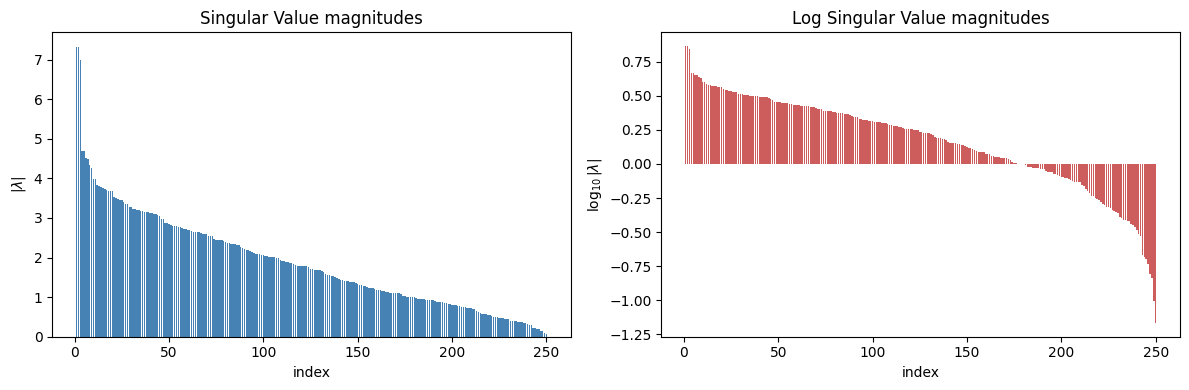

Q-function


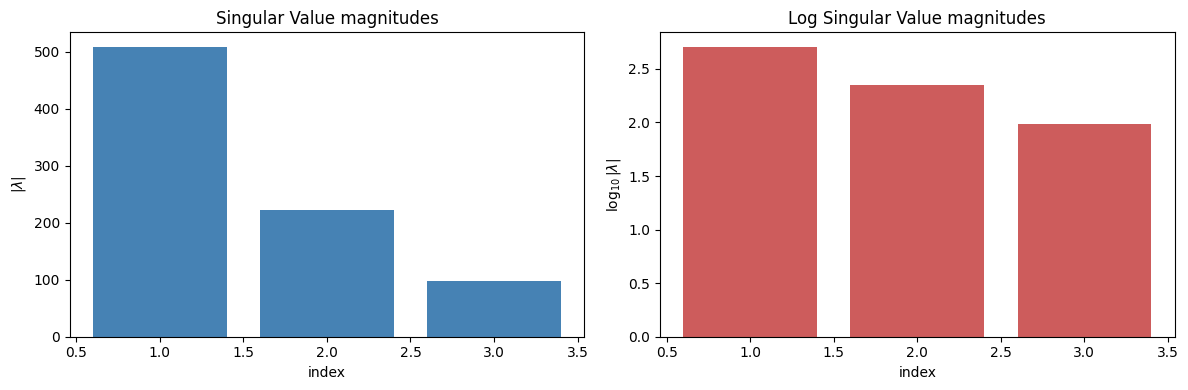

  2%|▏         | 11/500 [00:18<08:42,  1.07s/it] 

episode 10 avg_rewarg: -450.1


  4%|▍         | 21/500 [00:30<10:18,  1.29s/it]

episode 20 avg_rewarg: -471.4


  6%|▌         | 31/500 [00:43<10:37,  1.36s/it]

episode 30 avg_rewarg: -500.0


  8%|▊         | 41/500 [00:55<09:21,  1.22s/it]

episode 40 avg_rewarg: -474.1


 10%|█         | 50/500 [01:08<09:50,  1.31s/it]

episode 50 avg_rewarg: -500.0
Hankel Value Function


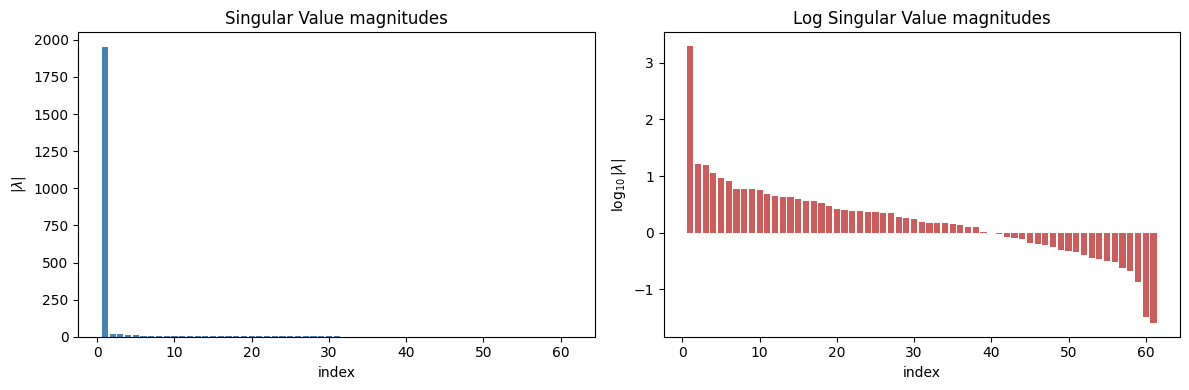

Q-function


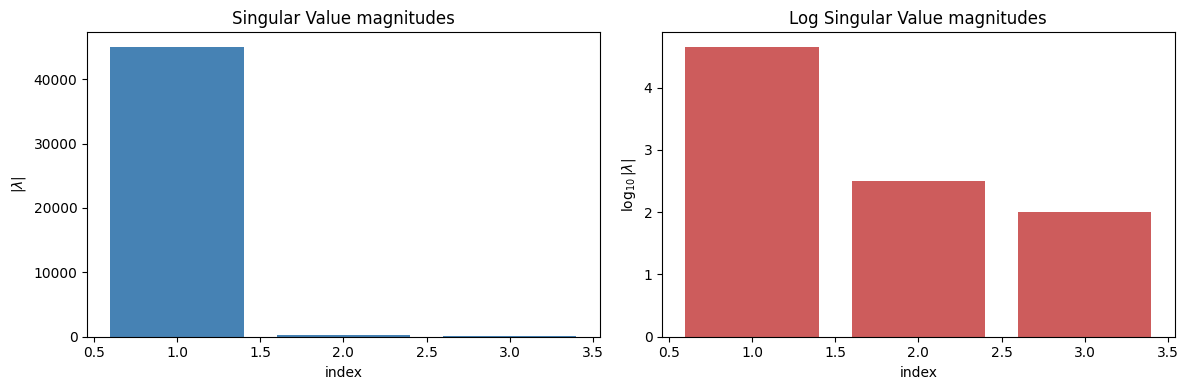

 12%|█▏        | 61/500 [01:19<05:05,  1.44it/s]

episode 60 avg_rewarg: -153.5


 14%|█▍        | 71/500 [01:27<05:51,  1.22it/s]

episode 70 avg_rewarg: -197.5


 16%|█▌        | 81/500 [01:35<05:40,  1.23it/s]

episode 80 avg_rewarg: -178.3


 18%|█▊        | 91/500 [01:42<05:36,  1.22it/s]

episode 90 avg_rewarg: -140.8


 20%|██        | 100/500 [01:48<04:38,  1.43it/s]

episode 100 avg_rewarg: -134.6
Hankel Value Function


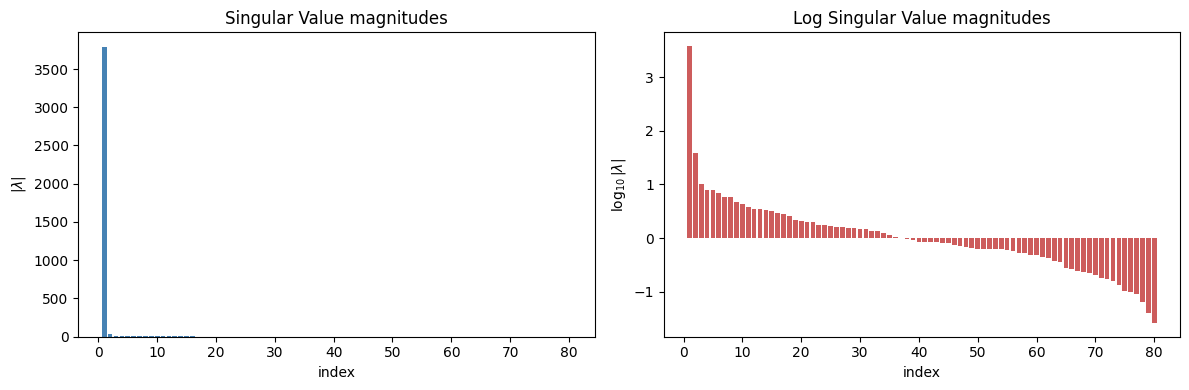

Q-function


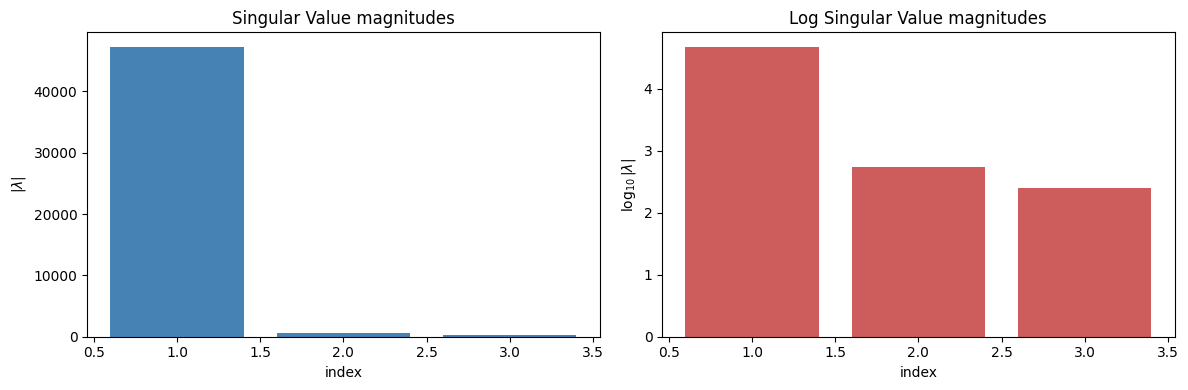

 22%|██▏       | 111/500 [02:02<05:46,  1.12it/s]

episode 110 avg_rewarg: -163.2


 24%|██▍       | 121/500 [02:09<04:34,  1.38it/s]

episode 120 avg_rewarg: -119.7


 26%|██▌       | 131/500 [02:16<04:15,  1.45it/s]

episode 130 avg_rewarg: -134.4


 28%|██▊       | 141/500 [02:24<04:17,  1.39it/s]

episode 140 avg_rewarg: -176.6


 30%|███       | 150/500 [02:30<03:49,  1.52it/s]

episode 150 avg_rewarg: -142.7
Hankel Value Function


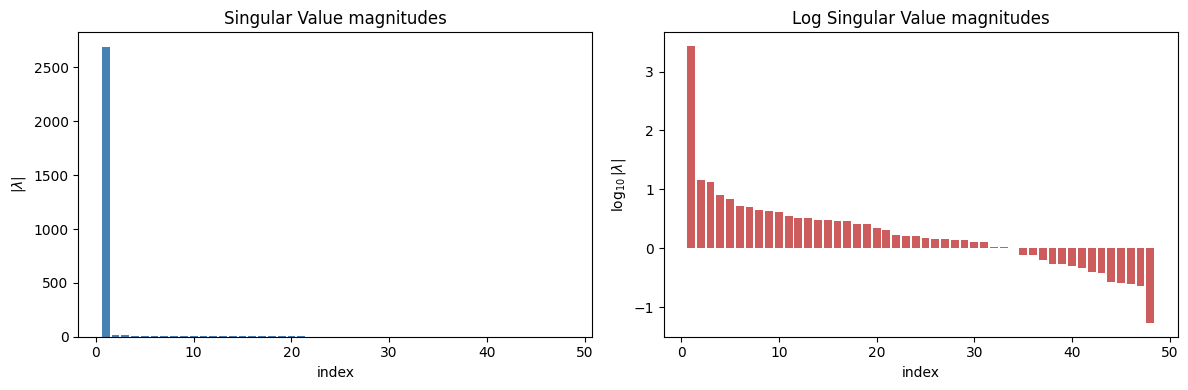

Q-function


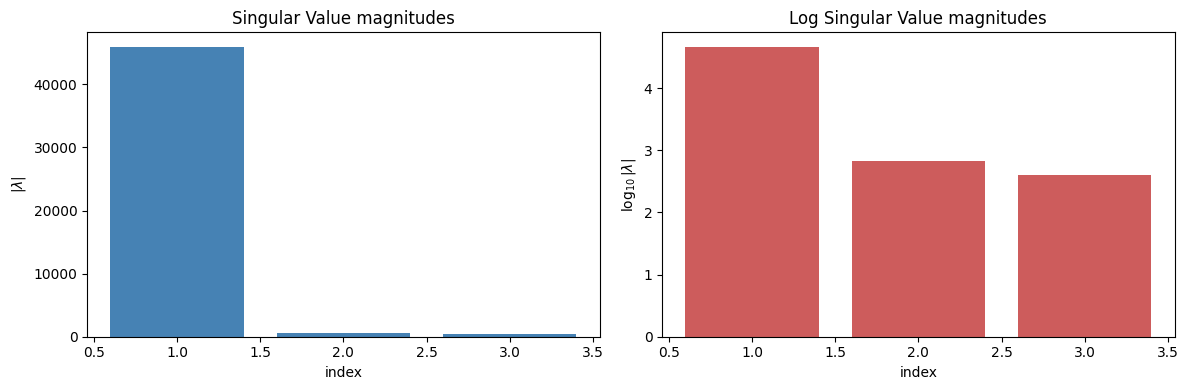

 32%|███▏      | 161/500 [02:44<05:02,  1.12it/s]

episode 160 avg_rewarg: -136.4


 34%|███▍      | 171/500 [02:50<03:32,  1.55it/s]

episode 170 avg_rewarg: -108.0


 36%|███▌      | 181/500 [02:57<03:33,  1.49it/s]

episode 180 avg_rewarg: -114.1


 38%|███▊      | 191/500 [03:03<03:12,  1.60it/s]

episode 190 avg_rewarg: -111.2


 40%|████      | 200/500 [03:09<02:56,  1.70it/s]

episode 200 avg_rewarg: -99.4
Hankel Value Function


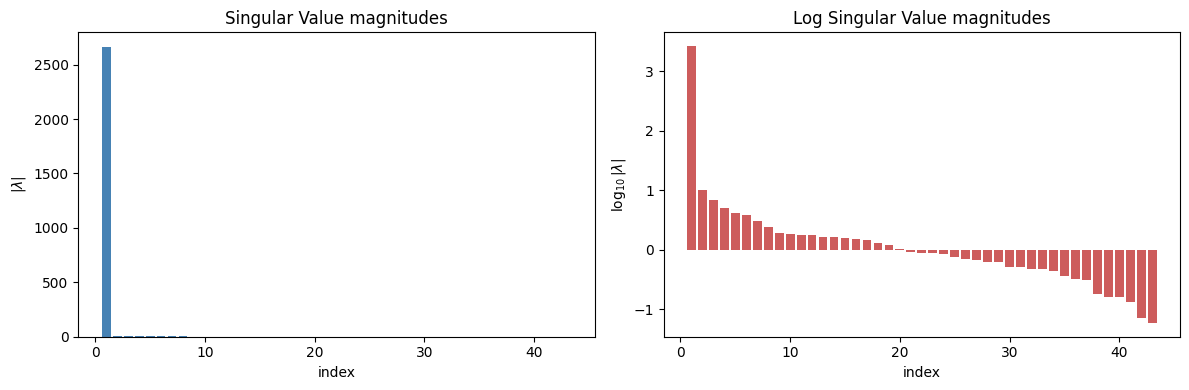

Q-function


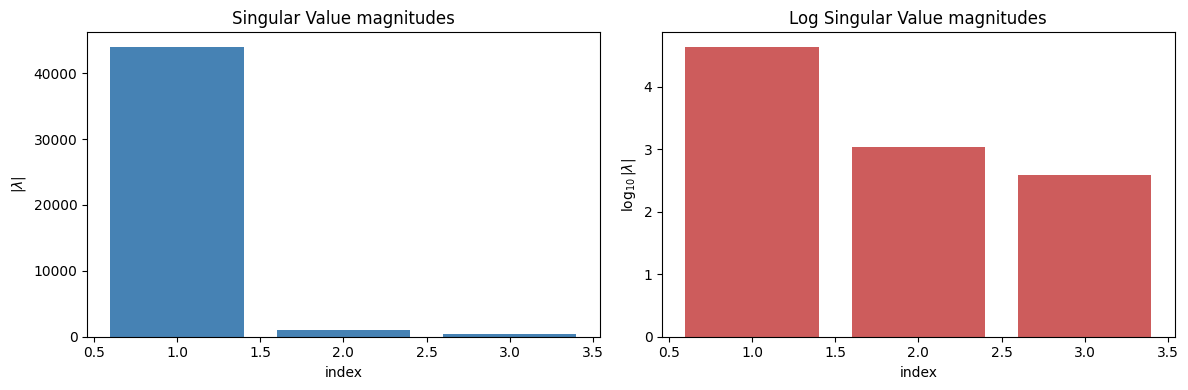

 42%|████▏     | 211/500 [03:20<03:22,  1.43it/s]

episode 210 avg_rewarg: -108.4


 44%|████▍     | 221/500 [03:26<03:05,  1.50it/s]

episode 220 avg_rewarg: -106.0


 46%|████▌     | 231/500 [03:33<02:35,  1.73it/s]

episode 230 avg_rewarg: -89.9


 48%|████▊     | 241/500 [03:39<02:28,  1.74it/s]

episode 240 avg_rewarg: -87.7


 50%|█████     | 250/500 [03:44<02:14,  1.86it/s]

episode 250 avg_rewarg: -84.4
Hankel Value Function


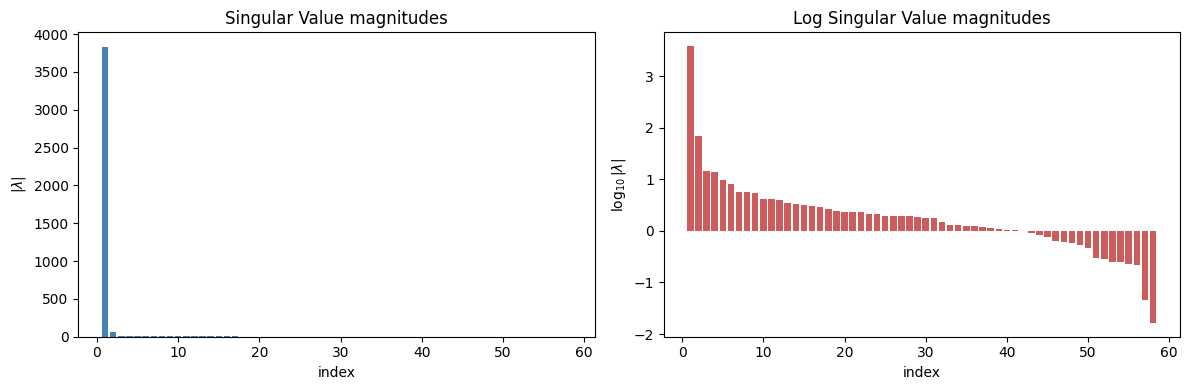

Q-function


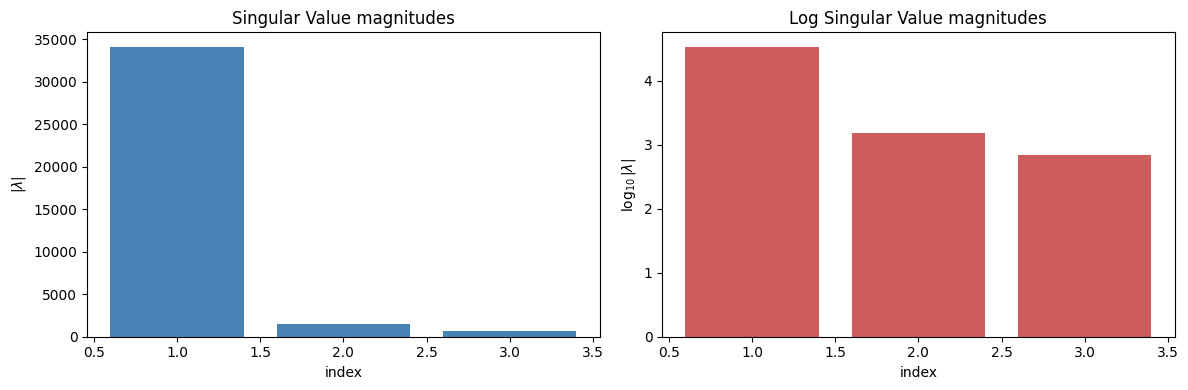

 52%|█████▏    | 261/500 [03:56<02:33,  1.56it/s]

episode 260 avg_rewarg: -90.7


 54%|█████▍    | 271/500 [04:02<02:11,  1.74it/s]

episode 270 avg_rewarg: -98.7


 56%|█████▌    | 281/500 [04:07<01:58,  1.85it/s]

episode 280 avg_rewarg: -93.4


 58%|█████▊    | 291/500 [04:14<02:28,  1.41it/s]

episode 290 avg_rewarg: -97.8


 60%|██████    | 300/500 [04:21<02:14,  1.48it/s]

episode 300 avg_rewarg: -108.7
Hankel Value Function


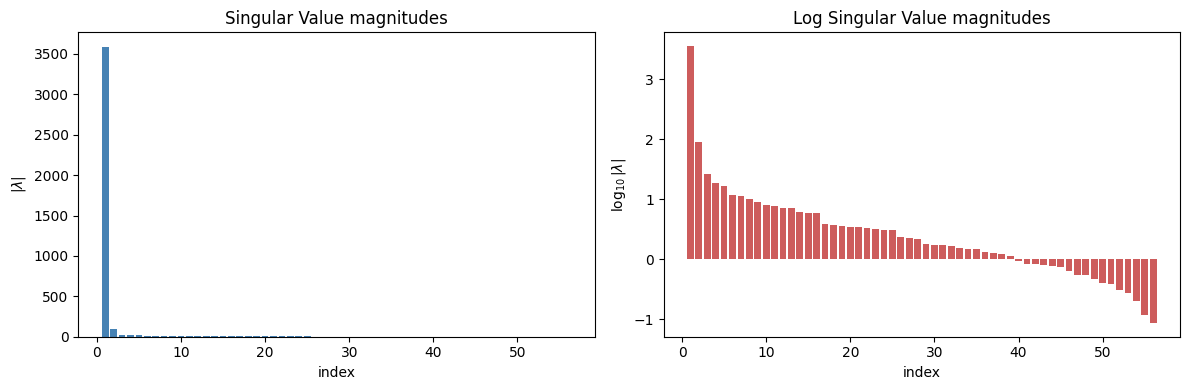

Q-function


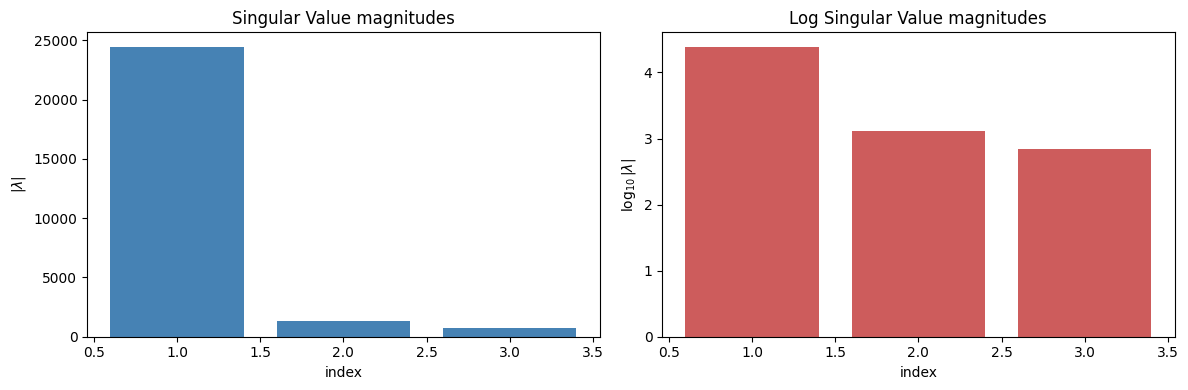

 62%|██████▏   | 311/500 [04:33<02:28,  1.27it/s]

episode 310 avg_rewarg: -98.1


 64%|██████▍   | 321/500 [04:38<01:39,  1.80it/s]

episode 320 avg_rewarg: -86.6


 66%|██████▌   | 331/500 [04:45<01:43,  1.63it/s]

episode 330 avg_rewarg: -96.4


 68%|██████▊   | 341/500 [04:51<01:36,  1.64it/s]

episode 340 avg_rewarg: -88.5


 70%|███████   | 350/500 [04:57<01:43,  1.45it/s]

episode 350 avg_rewarg: -87.0
Hankel Value Function


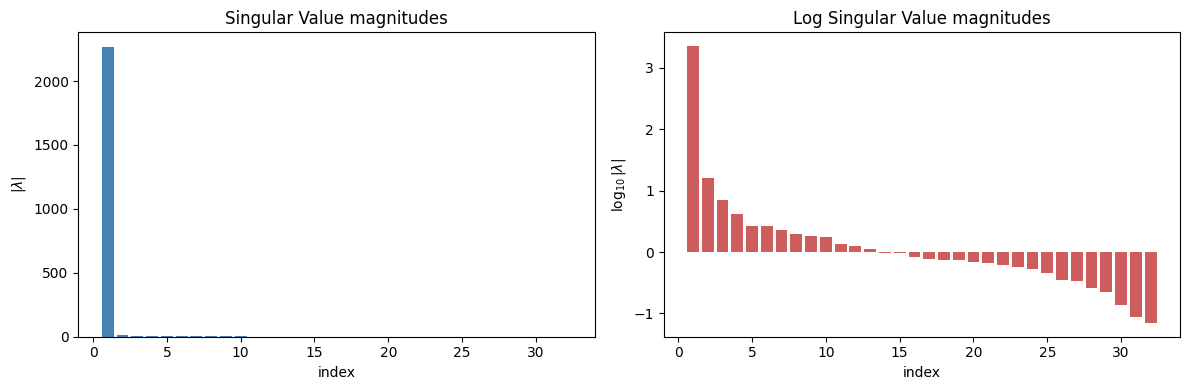

Q-function


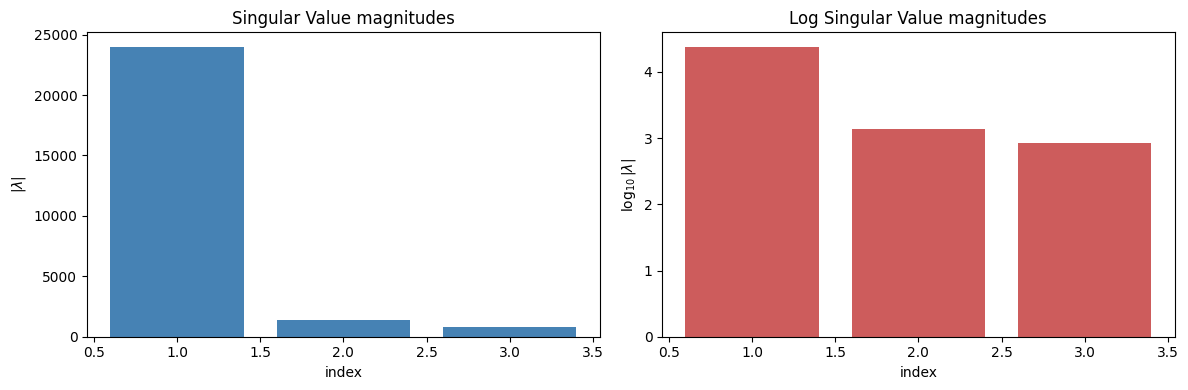

 72%|███████▏  | 361/500 [05:08<01:37,  1.43it/s]

episode 360 avg_rewarg: -94.0


 74%|███████▍  | 371/500 [05:14<01:20,  1.60it/s]

episode 370 avg_rewarg: -92.5


 76%|███████▌  | 381/500 [05:20<01:09,  1.72it/s]

episode 380 avg_rewarg: -80.1


 78%|███████▊  | 391/500 [05:27<01:09,  1.56it/s]

episode 390 avg_rewarg: -90.1


 80%|████████  | 400/500 [05:33<01:10,  1.42it/s]

episode 400 avg_rewarg: -83.6
Hankel Value Function


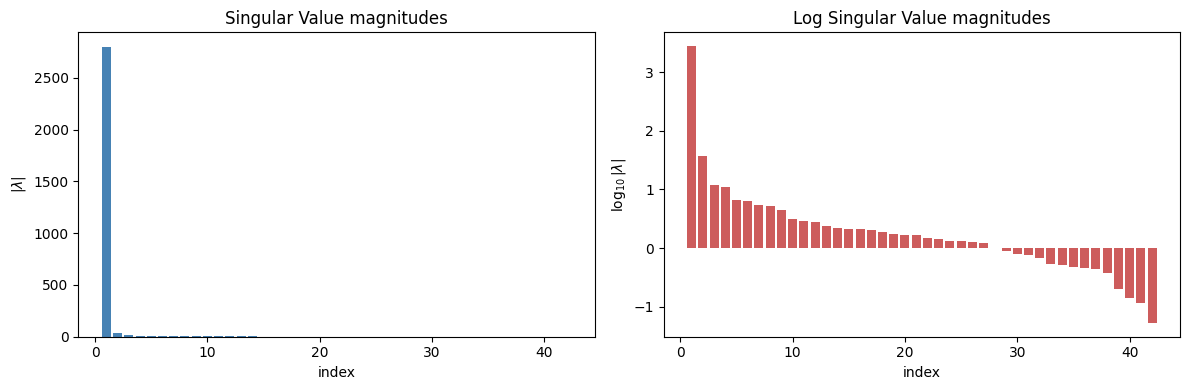

Q-function


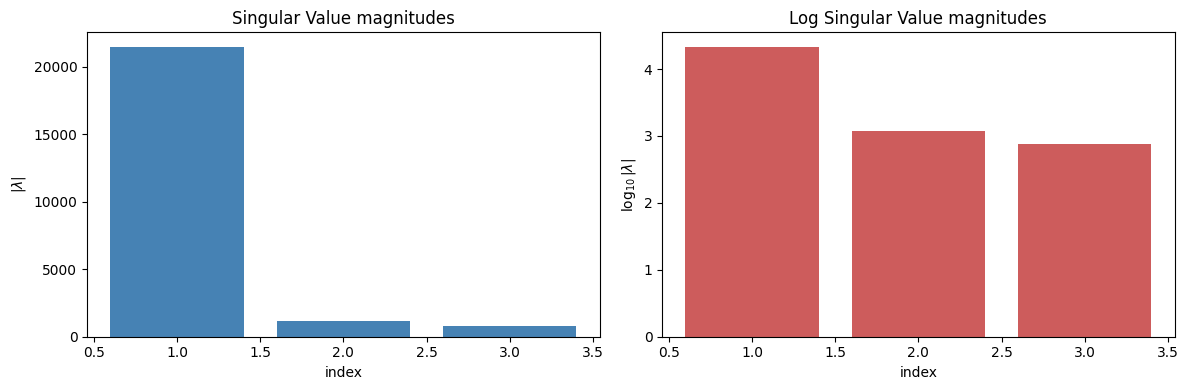

 82%|████████▏ | 411/500 [05:44<01:03,  1.40it/s]

episode 410 avg_rewarg: -84.9


 84%|████████▍ | 421/500 [05:51<00:52,  1.52it/s]

episode 420 avg_rewarg: -88.9


 86%|████████▌ | 431/500 [05:57<00:48,  1.43it/s]

episode 430 avg_rewarg: -102.6


 88%|████████▊ | 441/500 [06:04<00:43,  1.35it/s]

episode 440 avg_rewarg: -96.7


 90%|█████████ | 450/500 [06:10<00:37,  1.33it/s]

episode 450 avg_rewarg: -80.4
Hankel Value Function


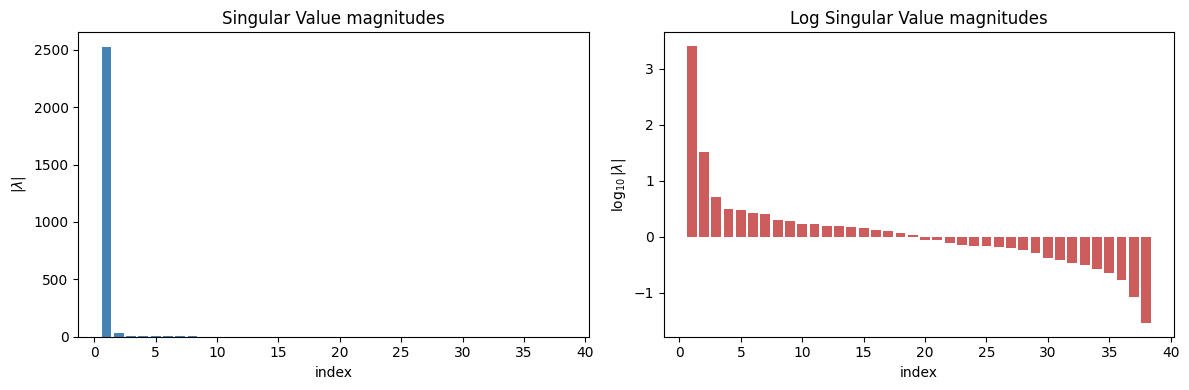

Q-function


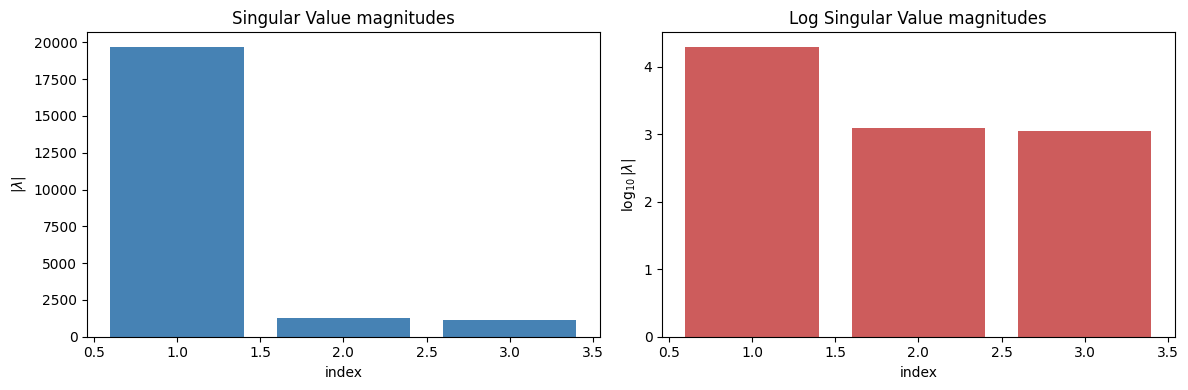

 92%|█████████▏| 461/500 [06:20<00:23,  1.70it/s]

episode 460 avg_rewarg: -79.6


 94%|█████████▍| 471/500 [06:25<00:14,  1.96it/s]

episode 470 avg_rewarg: -82.3


 96%|█████████▌| 481/500 [06:31<00:10,  1.83it/s]

episode 480 avg_rewarg: -93.9


 98%|█████████▊| 491/500 [06:36<00:04,  1.91it/s]

episode 490 avg_rewarg: -82.3


100%|██████████| 500/500 [06:41<00:00,  1.25it/s]


In [7]:
t = cfg["training"]
rewards = dqn_training_loop(
    agent, env,
    no_episodes=t["no_episodes"],
    target_network_update_steps=t["target_network_update_steps"],
    np_seed=seed,
    analysis_config = analysis
)

## Training and Analysis Plots (now with pi*(theeta))

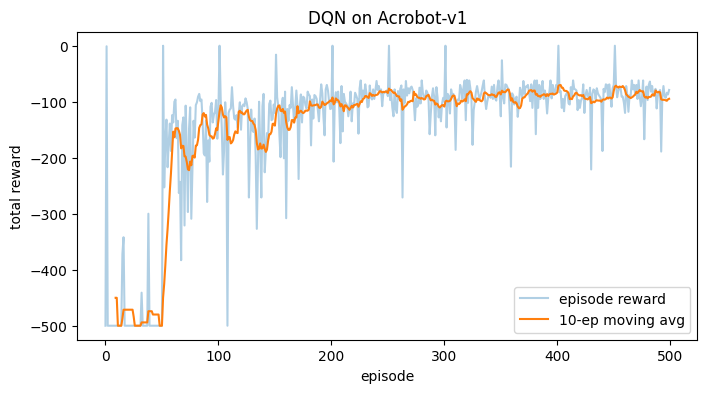

In [8]:
rewards = np.asarray(rewards, dtype=float)
plt.figure(figsize=(8, 4))
plt.plot(rewards, alpha=0.35, label="episode reward")
if len(rewards) >= 10:
    k = 10
    ma = np.convolve(rewards, np.ones(k) / k, mode="valid")
    plt.plot(range(k - 1, len(rewards)), ma, label=f"{k}-ep moving avg")
plt.xlabel("episode"); plt.ylabel("total reward"); plt.title("DQN on Acrobot-v1")
plt.legend(); plt.show()

Hankel Value Function


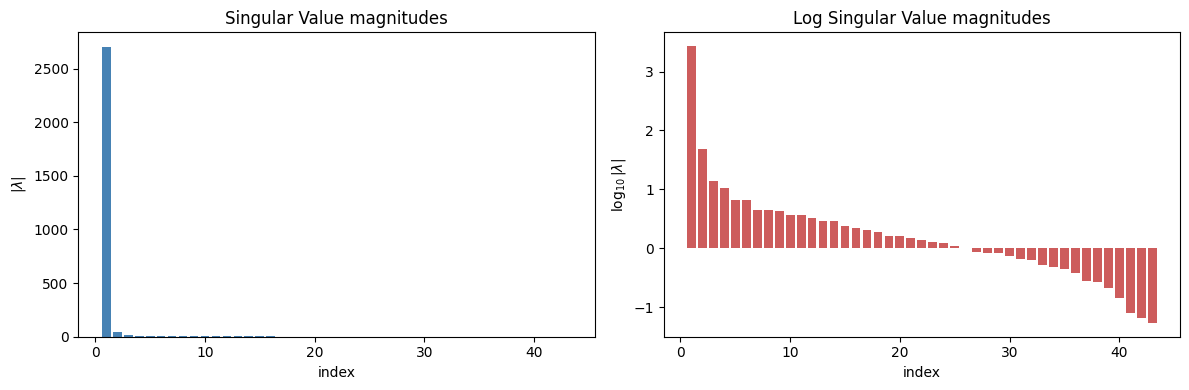

Q-function


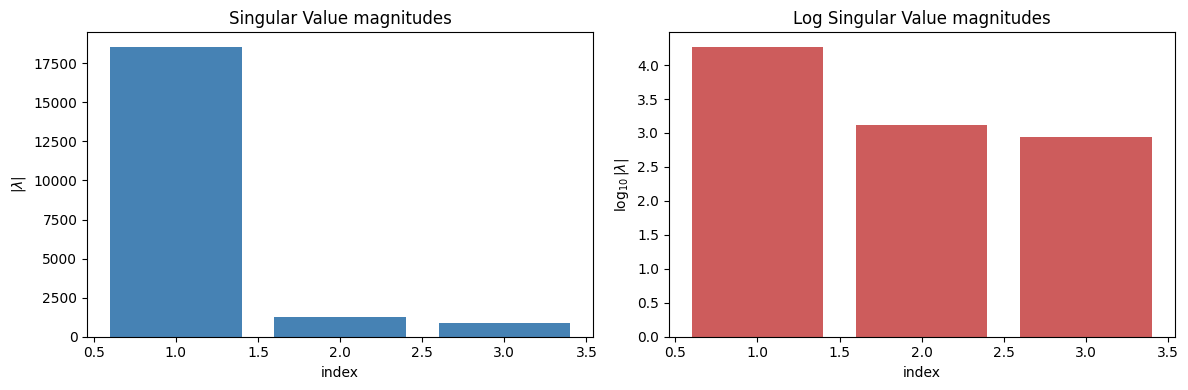

In [12]:
for method,name in zip(analysis["methods"], ['Hankel Value Function','Q-function']):
    print(name)
    matrix = method(agent=agent, env=env)
    plot_matrix_spectra(matrix)